In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Ejecutado")

Ejecutado


In [5]:
data_dir_1 = Path(r"../data/tesis/curated_axis_sym_obj/curated_axis_sym_obj")
data_dir_2 = Path(r"../data/tesis/curated_plane_sym_obj/curated_plane_sym_obj_ori")

if not data_dir_1.exists():
    raise FileNotFoundError(f"No existe la carpeta: {data_dir_1}")

if not data_dir_2.exists():
    raise FileNotFoundError(f"No existe la carpeta: {data_dir_2}")
    
print(f"Carpetas encontradas: {data_dir_1} y {data_dir_2}")

Carpetas encontradas: ../data/tesis/curated_axis_sym_obj/curated_axis_sym_obj y ../data/tesis/curated_plane_sym_obj/curated_plane_sym_obj_ori


In [6]:
def count_symmetries_from_txt(txt_path: Path) -> int:
    """
    Lee la primera linea del archivo .txt como numero de simetrias.
    Si falla, intenta contar lineas que empiezan con 'plane' o 'axis']
    .
    """
    with txt_path.open('r', encoding='utf-8', errors='ignore') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        return 0

    # Formato esperado: primera linea = numero entero
    try:
        return int(lines[0])
    except ValueError:
        pass

    # Fallback robusto
    return sum(1 for line in lines if line.lower().startswith(('plane', 'axis')))


def count_vertices_from_obj(obj_path: Path) -> int:
    """Cuenta lineas de vertices en un OBJ: lineas que empiezan con 'v '."""
    count = 0
    with obj_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.startswith('v '):
                count += 1
    return count

In [10]:
obj_files_AXIAL = sorted(data_dir_1.glob('*.obj'))
txt_files_AXIAL = sorted(data_dir_1.glob('*.txt'))

print(f"OBJ encontrados AXIAL: {len(obj_files_AXIAL)}")
print(f"TXT encontrados AXIAL: {len(txt_files_AXIAL)}")



obj_files_PLANAR = sorted(data_dir_2.glob('*.obj'))
txt_files_PLANAR = sorted(data_dir_2.glob('*.txt'))

print(f"OBJ encontrados PLANAR: {len(obj_files_PLANAR)}")
print(f"TXT encontrados PLANAR: {len(txt_files_PLANAR)}")

OBJ encontrados AXIAL: 850
TXT encontrados AXIAL: 850
OBJ encontrados PLANAR: 850
TXT encontrados PLANAR: 850


In [21]:
obj_files = obj_files_PLANAR
txt_files = txt_files_PLANAR

# Unimos por stem (nombre base sin extension)
obj_map = {p.stem: p for p in obj_files}
txt_map = {p.stem: p for p in txt_files}
all_ids = sorted(set(obj_map.keys()) | set(txt_map.keys()))

rows = []
for obj_id in all_ids:
    obj_path = obj_map.get(obj_id)
    txt_path = txt_map.get(obj_id)

    vertex_count = np.nan
    sym_count = np.nan

    if obj_path is not None:
        vertex_count = count_vertices_from_obj(obj_path)

    if txt_path is not None:
        sym_count = count_symmetries_from_txt(txt_path)

    rows.append({
        'object_id': obj_id,
        'vertex_count': vertex_count,
        'symmetry_count': sym_count,
        'has_obj': obj_path is not None,
        'has_txt': txt_path is not None,
    })

df = pd.DataFrame(rows)
df.head()

,object_id,vertex_count,symmetry_count,has_obj,has_txt
0,10654ea604644c8eca7ed590d69b9804,266,1,True,True
1,1074bdcb3c2032fe0f3f8b6e1796773,460,1,True,True
2,109a19840a8fbc774c3aee8e9d3a6ffa,400,1,True,True
3,10b54fe832a00c3ec59350d819542ec7,372,1,True,True
4,10c484963692d3c87d40405e5ee68b4f,207,1,True,True


In [22]:
# Verificamos consistencia de pares OBJ/TXT
missing_obj = df[df['has_txt'] & ~df['has_obj']]
missing_txt = df[df['has_obj'] & ~df['has_txt']]

print('Objetos con TXT pero sin OBJ:', len(missing_obj))
print('Objetos con OBJ pero sin TXT:', len(missing_txt))

if len(missing_obj) > 0:
    display(missing_obj[['object_id']].head(10))
if len(missing_txt) > 0:
    display(missing_txt[['object_id']].head(10))

Objetos con TXT pero sin OBJ: 0
Objetos con OBJ pero sin TXT: 0


In [23]:
# Dataset limpio para EDA principal
df_clean = df[df['has_obj'] & df['has_txt']].copy()

df_clean['vertex_count'] = df_clean['vertex_count'].astype(int)
df_clean['symmetry_count'] = df_clean['symmetry_count'].astype(int)

print('Total objetos validos:', len(df_clean))
df_clean.describe()

Total objetos validos: 850


,vertex_count,symmetry_count
count,850.000000,850.000000
mean,5449.145882,1.192941
std,7784.360095,0.412350
min,191.000000,1.000000
25%,882.000000,1.000000
50%,2143.000000,1.000000
75%,6687.750000,1.000000
max,75563.000000,3.000000


In [24]:
# Recuento de cantidad de simetrias
sym_counts = df_clean['symmetry_count'].value_counts().sort_index()
sym_counts

symmetry_count
1    692
2    152
3      6
Name: count, dtype: int64

In [25]:
# Complejidad por vertices: top 10 objetos mas complejos
df_top_complex = df_clean.sort_values('vertex_count', ascending=False).head(10)
df_top_complex[['object_id', 'vertex_count', 'symmetry_count']]

,object_id,vertex_count,symmetry_count
531,8843d862a7545d0d96db382b382d7132,75563,1
407,693b8a150f9e844e50539bb73fa8aaff,47832,1
41,193fdf550fd5f12f446f92b52bbd82a,46235,1
158,303555f1c5f4cb0a1082f2ea630bf69e,43594,2
374,619b49bae27807fb1082f2ea630bf69e,42861,1
194,393ca71bd734f3071082f2ea630bf69e,39931,1
16,141616a00df67c351082f2ea630bf69e,39402,1
423,6c3e80092fa36371cb2ecbd32dc2119e,38461,1
295,4ead9b28515b97fdc0e2e9e9ade4d03b,37987,1
389,643191e8ee56104e424f8f8e828c9ab9,35385,1


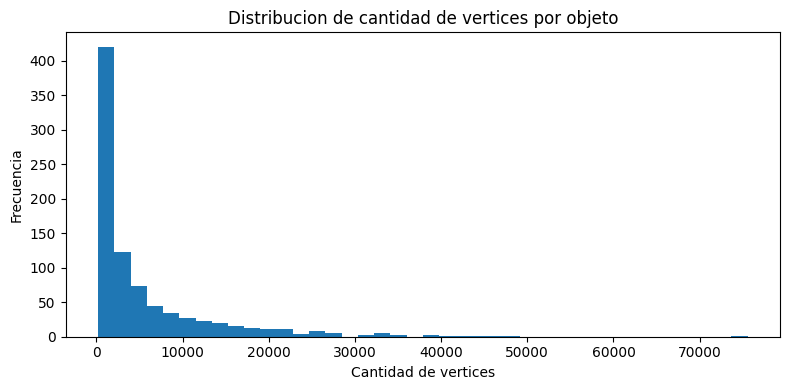

In [26]:
# Histograma de vertices
plt.figure(figsize=(8, 4))
plt.hist(df_clean['vertex_count'], bins=40)
plt.title('Distribucion de cantidad de vertices por objeto')
plt.xlabel('Cantidad de vertices')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

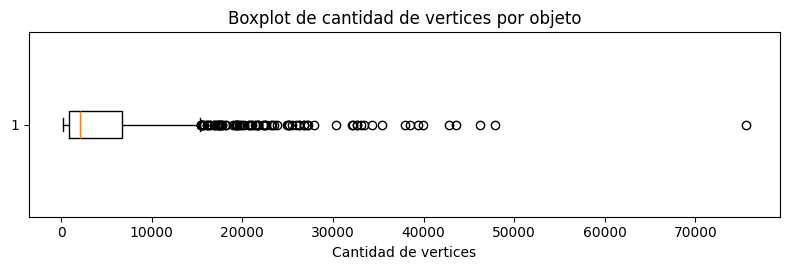

In [27]:
# Boxplot de vertices para visualizar mediana, rango intercuartil y outliers
plt.figure(figsize=(8, 2.8))
plt.boxplot(df_clean['vertex_count'], vert=False)
plt.title('Boxplot de cantidad de vertices por objeto')
plt.xlabel('Cantidad de vertices')
plt.tight_layout()
plt.show()

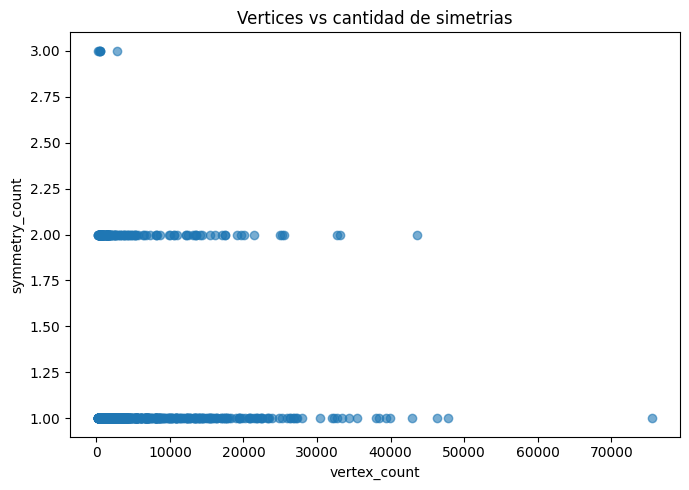

In [28]:
# Relacion entre complejidad y simetrias
plt.figure(figsize=(7, 5))
plt.scatter(df_clean['vertex_count'], df_clean['symmetry_count'], alpha=0.6)
plt.title('Vertices vs cantidad de simetrias')
plt.xlabel('vertex_count')
plt.ylabel('symmetry_count')
plt.tight_layout()
plt.show()